<a href="https://colab.research.google.com/github/DanieleBaiocco/IPCV_assignment1/blob/main/assignment_module_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Product Recognition of Food Products**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it


Computer vision-based object detection techniques can be applied in super market settings to build a system that can identify products on store shelves.
An example of how this system could be used would be to assist visually impaired customers or automate common store management tasks like detecting low-stock or misplaced products, given an image of a shelf in a store.

## Task
Develop a computer vision system that, given a reference image for each product, is able to identify such product from one picture of a store shelf.

<figure>
<a href="https://imgbb.com/">
  <center>
  <img src="https://i.ibb.co/TwkMWnH/Screenshot-2024-04-04-at-14-54-51.png" alt="Screenshot-2024-04-04-at-14-54-51" border="0" width="300" />
</a>
</figure>

For each type of product displayed in the
shelf the system should report:
1. Number of instances;
1. Dimension of each instance (width and height in pixel of the bounding box that enclose them);
1. Position in the image reference system of each instance (center of the bounding box that enclose them).

#### Example of expected output
```
Product 0 - 2 instance found:
  Instance 1 {position: (256, 328), width: 57px, height: 80px}
  Instance 2 {position: (311, 328), width: 57px, height: 80px}
Product 1 – 1 instance found:
.
.
.
```

### Track A - Single Instance Detection
Develop an object detection system to identify single instance of products given one reference image for each item and a scene image.

The system should be able to correctly identify all the product in the shelves
image.

### Track B - Multiple Instances Detection
In addition to what achieved at step A, the system should also be able to detect multiple instances of the same product.

## Data
Two folders of images are provided:
* **Models**: contains one reference image for each product that the system should be able to identify.
* **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios. The images contained in this folder are corrupted by noise.

#### Track A - Single Instance Detection
* **Models**: {ref1.png to ref14.png}.
* **Scenes**: {scene1.png to scene5.png}.

#### Track B - Multiple Instances Detection
* **Models**: {ref15.png to ref27.png}.
* **Scenes**: {scene6.png to scene12.png}.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Evaluation criteria
1. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

2. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed approach.

In [2]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

# LOADING IMAGES
The images are loaded from OneDrive onto this Google Colab.
I loaded and stored the scene and reference images for the tracks A and B according to the trace.

**Only** for the reference images of both track A and B I applied a pipeline of deblurring:
1. First of all I applied a **median filter** with kernel of size 5, because the source reference images had massive *salt-and-pepper* noise.
2. I then applied a **bilateral filter**, because it keeps the edges sharp while denoising the image. The bilateral filter parameters
3. Due to the significant blurring in the images, I applied a **non-local means filter**. This filter enhances the image by denoising each pixel based on the similarity of small patches within a larger search window around the target pixel. Unlike traditional filters that consider only spatially close pixels, the non-local means filter finds and averages similar patches regardless of their spatial distance. This approach effectively homogenizes surfaces of the same color, leading to a more uniform appearance and reducing the overall noise while preserving important details and edges.

In order to find the right parameters for these filters I have tried a lot of different configurations.

In [3]:
def create_list_of_paths(directory):
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp')
    image_files = [
        filename for filename in os.listdir(directory)
        if os.path.isfile(os.path.join(directory, filename))
        and filename.lower().endswith(valid_extensions)
    ]
    image_files.sort(key=str.lower)
    image_files = [os.path.join(directory, image_file) for image_file in image_files]
    return image_files


In [4]:
images_directory = '/content/drive/MyDrive/a/content/dataset'
reference_directory = os.path.join(images_directory, 'models')
scene_directory =  os.path.join(images_directory, 'scenes')
reference_files = create_list_of_paths(reference_directory)
scene_files = create_list_of_paths(scene_directory)

An **Image** class is defined to store the label of each image for visualization purposes and to handle image deblurring.

In [5]:
class Image:
    def __init__(self, path, preprocess):
        self.image = None
        # by default imread reads the image as rgb
        image = cv2.imread(path)
        if preprocess:
          self._preprocess_image(image)
        else:
          self.image = image
        self.label = os.path.splitext(os.path.basename(path))[0].replace('_', ' ')

    def _preprocess_image(self, image):
        image = cv2.medianBlur(image, ksize = 5)
        image = cv2.bilateralFilter(image, d=11, sigmaColor=75, sigmaSpace=20)
        self.image = cv2.fastNlMeansDenoisingColored(image, None, h=7,hColor=10,templateWindowSize =5,searchWindowSize =25)

In [6]:
def create_images(list_of_paths, preprocess = False):
  images = []
  for path in list_of_paths:
    image = Image(path, preprocess)
    images.append(image)
  return images

In [7]:
reference_images = create_images(reference_files)
scene_images = create_images(scene_files, preprocess=False)

print(f'Loaded {len(reference_images)} reference images')
print(f'Loaded {len(scene_images)} scene images')

Loaded 8 reference images
Loaded 1 scene images


## Debug 1 — Visualizzazione delle immagini caricate

Le immagini OpenCV sono in formato BGR; per mostrarle correttamente con Matplotlib vengono convertite in RGB.
Queste celle non modificano le immagini usate dalla detection.


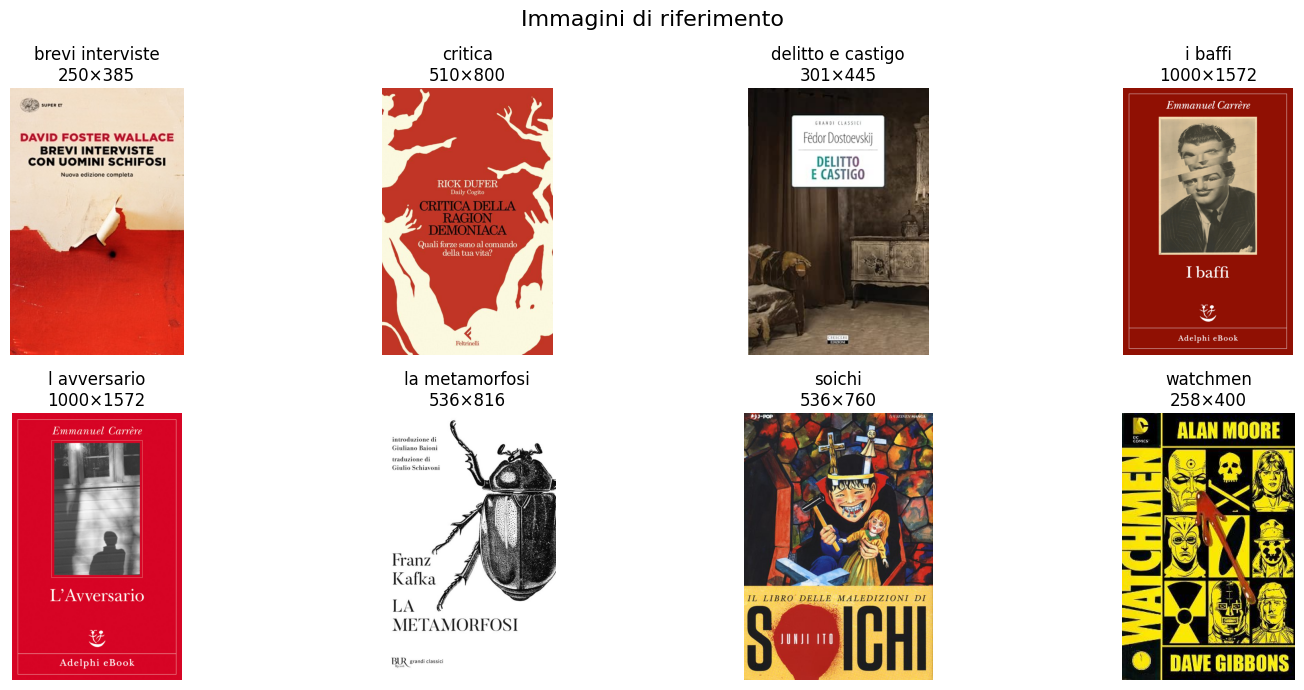

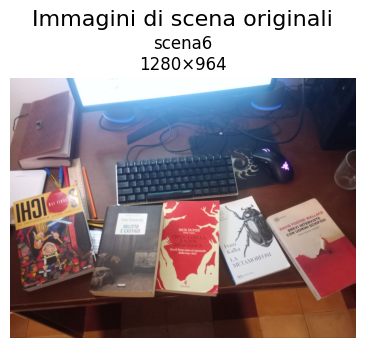

In [8]:
def show_image_collection(image_objects, title, max_columns=4):
    number_of_images = len(image_objects)

    if number_of_images == 0:
        print(f"{title}: nessuna immagine caricata")
        return

    columns = min(max_columns, number_of_images)
    rows = int(np.ceil(number_of_images / columns))

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(4 * columns, 3.5 * rows)
    )

    axes = np.atleast_1d(axes).ravel()

    for axis, image_object in zip(axes, image_objects):
        rgb_image = cv2.cvtColor(
            image_object.image,
            cv2.COLOR_BGR2RGB
        )

        axis.imshow(rgb_image)
        axis.set_title(
            f"{image_object.label}\n"
            f"{image_object.image.shape[1]}×{image_object.image.shape[0]}"
        )
        axis.axis("off")

    for axis in axes[number_of_images:]:
        axis.axis("off")

    figure.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_image_collection(
    reference_images,
    "Immagini di riferimento"
)

show_image_collection(
    scene_images,
    "Immagini di scena originali"
)


## Debug 2 — Preprocessing leggero e opzionale delle scene

Il preprocessing originale applicava più filtri di denoising e blur. Qui viene proposto soltanto **CLAHE sul canale di luminosità**, per aumentare il contrasto locale senza sfocare i dettagli.

È disattivato per impostazione predefinita. Confronta prima le immagini e il numero di good match; abilitalo solo se migliora realmente i risultati.


In [ ]:
def light_scene_preprocessing(image):
    """
    Aumenta moderatamente il contrasto locale sul solo canale
    di luminosità, senza applicare blur o denoising.
    """
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    lightness, channel_a, channel_b = cv2.split(lab_image)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced_lightness = clahe.apply(lightness)

    enhanced_lab = cv2.merge(
        (enhanced_lightness, channel_a, channel_b)
    )

    return cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2BGR
    )


# Manteniamo una copia logica delle scene originali.
scene_images_original = scene_images

# Rileggiamo le scene per creare una variante indipendente.
scene_images_light_preprocessed = create_images(
    scene_files,
    preprocess=False
)

for scene_object in scene_images_light_preprocessed:
    scene_object.image = light_scene_preprocessing(
        scene_object.image
    )


def compare_scene_versions(
    original_scene_objects,
    processed_scene_objects
):
    for original_object, processed_object in zip(
        original_scene_objects,
        processed_scene_objects
    ):
        figure, axes = plt.subplots(
            1,
            2,
            figsize=(14, 6)
        )

        axes[0].imshow(
            cv2.cvtColor(
                original_object.image,
                cv2.COLOR_BGR2RGB
            )
        )
        axes[0].set_title(
            f"{original_object.label} — originale"
        )
        axes[0].axis("off")

        axes[1].imshow(
            cv2.cvtColor(
                processed_object.image,
                cv2.COLOR_BGR2RGB
            )
        )
        axes[1].set_title(
            f"{processed_object.label} — CLAHE leggero"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


compare_scene_versions(
    scene_images_original,
    scene_images_light_preprocessed
)

# False: la detection usa le immagini originali.
# True: la detection usa le scene con CLAHE leggero.
USE_LIGHT_SCENE_PREPROCESSING = True

scene_images = (
    scene_images_light_preprocessed
    if USE_LIGHT_SCENE_PREPROCESSING
    else scene_images_original
)

print(
    "Scene usate dalla detection:",
    "CLAHE leggero"
    if USE_LIGHT_SCENE_PREPROCESSING
    else "originali senza preprocessing"
)


# Single-object detection helper (former Track A)
The original Track A algorithm is retained because it is used internally by the multi-object detection procedure.
For a scene image, it performs the following steps:
* For each reference image
  * It runs the SIFT algorithm.
  * If the number of matches is higher than a threshold, the reference is considered a candidate match.
  * It stores the match and its homography.
* It computes the bounding boxes from the homographies.
* It compares overlapping bounding boxes and keeps the candidate with the highest number of matches.

This helper is not executed as a separate task in the unified pipeline.

The method `compute_flann_2NN_matching` returns a function that performs match between **feature descriptors** of the query and the target **images**. It computes two neighborhoods for each match, and then it uses the **ratio test** to select only matches in which the closest match *m* is  significantly smaller than the distance of the second closest match *n*.

In [ ]:
# Define the outer function to set up the FLANN-based matcher
def compute_flann_2NN_matching(flann_index_kdtree, trees, checks):
  index_params = dict(algorithm = flann_index_kdtree, trees = trees)
  search_params = dict(checks = checks)
  flann = cv2.FlannBasedMatcher(index_params, search_params)
  # Define the nested function to compute FLANN 2NN matches
  def compute_flan(des_reference, des_scene):
      matches =  flann.knnMatch(des_reference,des_scene, k=2)
      good = []
      for m,n in matches:
          # Apply the ratio test to filter good matches
          if m.distance < 0.7*n.distance:
              good.append(m)
      return good
  # Return the nested function to compute FLANN 2NN matches
  return compute_flan

The method `compute_homography` This code sets up a function that, when called, will compute the homography matrix between two sets of matched keypoints using a specified method and reprojection threshold.

In [ ]:
# Define the outer function to configure the homography computation
def compute_homography(homography_method, ransacReprojThreshold):
  # Define the nested function to find the homography matrix
  def find_homography(matches, kp_reference, kp_scene):
    # Extract points from the reference keypoints based on the matches
    src_pts = np.float32([ kp_reference[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
    # Extract points from the scene keypoints based on the matches
    dst_pts = np.float32([ kp_scene[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)
    # Compute the homography matrix using the specified method and threshold
    M, mask = cv2.findHomography(src_pts, dst_pts, homography_method, ransacReprojThreshold)
    matchesMask = mask.ravel().tolist()
    return M, matchesMask
  return find_homography

In [ ]:
lambda_matcher = compute_flann_2NN_matching(flann_index_kdtree = 1, trees = 15, checks = 100)
lambda_homography = compute_homography(homography_method = cv2.RANSAC, ransacReprojThreshold = 5.0)

The function `sift_instance_detection` works on a scene image and a reference image. It does the following:
1. performs **SIFT feature detection** on both the source and the reference image
2. computes **SIFT descriptors** of these keypoints on both the source and the reference image
3. **matches these descriptors**
4. computes the **homography matrix** based on the matched keypoints
5. returns the **number of matches** and the **homography** matrix if a **sufficient number of matches are found**

In [ ]:
def sift_instance_detection(reference_image, scene_image, perform_matcher, min_match_count, compute_homography):
  sift = cv2.SIFT_create()
  kp_reference = sift.detect(reference_image)
  kp_scene = sift.detect(scene_image)
  kp_reference, des_reference = sift.compute(reference_image, kp_reference)
  kp_scene, des_scene = sift.compute(scene_image, kp_scene)
  matches = perform_matcher(des_reference,des_scene)
  if len(matches)<=min_match_count:
    return None
  M, mask = compute_homography(matches, kp_reference, kp_scene)
  return len(matches), M

## Debug 3 — Numero di similarità SIFT prima del cutoff

`good_matches` è il numero confrontato con `min_match_count` nella detection. Il report prova ogni riferimento contro ogni scena e mostra i candidati migliori.

Nota: nel codice attuale un risultato viene accettato solo quando `good_matches > min_match_count`. Quindi, con `min_match_count = 20`, servono almeno **21 good match**.


In [ ]:
def compute_sift_similarity_report(
    reference_objects,
    scene_objects,
    perform_matcher,
    min_match_count
):
    sift = cv2.SIFT_create()

    reference_features = {}
    for reference_object in reference_objects:
        keypoints, descriptors = sift.detectAndCompute(
            reference_object.image,
            None
        )
        reference_features[reference_object.label] = (
            keypoints,
            descriptors
        )

    scene_features = {}
    for scene_object in scene_objects:
        keypoints, descriptors = sift.detectAndCompute(
            scene_object.image,
            None
        )
        scene_features[scene_object.label] = (
            keypoints,
            descriptors
        )

    rows = []

    for scene_object in scene_objects:
        scene_keypoints, scene_descriptors = scene_features[
            scene_object.label
        ]

        for reference_object in reference_objects:
            reference_keypoints, reference_descriptors = (
                reference_features[reference_object.label]
            )

            good_matches_count = 0
            error = ""

            if (
                reference_descriptors is None
                or scene_descriptors is None
            ):
                error = "descrittori SIFT assenti"
            else:
                try:
                    good_matches = perform_matcher(
                        reference_descriptors,
                        scene_descriptors
                    )
                    good_matches_count = len(good_matches)
                except (cv2.error, ValueError) as exception:
                    error = str(exception)

            rows.append({
                "scene": scene_object.label,
                "reference": reference_object.label,
                "reference_keypoints": len(reference_keypoints),
                "scene_keypoints": len(scene_keypoints),
                "good_matches": good_matches_count,
                "passes_cutoff": (
                    good_matches_count > min_match_count
                ),
                "error": error
            })

    return pd.DataFrame(rows)


def show_sift_similarity_report(
    report,
    top_n_per_scene=10
):
    if report.empty:
        print("Nessun risultato da mostrare.")
        return

    for scene_label, scene_report in report.groupby(
        "scene",
        sort=False
    ):
        ordered_report = scene_report.sort_values(
            "good_matches",
            ascending=False
        )

        print(
            f"\nScena: {scene_label} — "
            f"migliori {min(top_n_per_scene, len(ordered_report))} "
            "riferimenti"
        )

        display(
            ordered_report[
                [
                    "reference",
                    "reference_keypoints",
                    "scene_keypoints",
                    "good_matches",
                    "passes_cutoff",
                    "error"
                ]
            ].head(top_n_per_scene)
        )



MIN_MATCH_COUNT_DEBUG = 20

# Calcoliamo entrambi i report per confrontare in modo oggettivo
# le scene originali con quelle preprocessate.
sift_report_original = compute_sift_similarity_report(
    reference_images,
    scene_images_original,
    lambda_matcher,
    MIN_MATCH_COUNT_DEBUG
)

sift_report_light_preprocessed = compute_sift_similarity_report(
    reference_images,
    scene_images_light_preprocessed,
    lambda_matcher,
    MIN_MATCH_COUNT_DEBUG
)

preprocessing_match_comparison = (
    sift_report_original[
        [
            "scene",
            "reference",
            "good_matches",
            "passes_cutoff"
        ]
    ]
    .rename(
        columns={
            "good_matches": "good_matches_original",
            "passes_cutoff": "passes_cutoff_original"
        }
    )
    .merge(
        sift_report_light_preprocessed[
            [
                "scene",
                "reference",
                "good_matches",
                "passes_cutoff"
            ]
        ].rename(
            columns={
                "good_matches": "good_matches_clahe",
                "passes_cutoff": "passes_cutoff_clahe"
            }
        ),
        on=["scene", "reference"],
        how="inner"
    )
)

preprocessing_match_comparison["match_delta"] = (
    preprocessing_match_comparison["good_matches_clahe"]
    - preprocessing_match_comparison["good_matches_original"]
)

preprocessing_summary = (
    preprocessing_match_comparison
    .groupby("scene", as_index=False)
    .agg(
        best_matches_original=("good_matches_original", "max"),
        best_matches_clahe=("good_matches_clahe", "max"),
        pairs_improved=(
            "match_delta",
            lambda values: int((values > 0).sum())
        ),
        pairs_worsened=(
            "match_delta",
            lambda values: int((values < 0).sum())
        ),
        detections_original=(
            "passes_cutoff_original",
            "sum"
        ),
        detections_clahe=(
            "passes_cutoff_clahe",
            "sum"
        )
    )
)

preprocessing_summary["best_match_delta"] = (
    preprocessing_summary["best_matches_clahe"]
    - preprocessing_summary["best_matches_original"]
)

print("Confronto sintetico: originale vs CLAHE leggero")
display(preprocessing_summary)

print(
    "\nCoppie riferimento–scena con i maggiori miglioramenti "
    "o peggioramenti:"
)
display(
    preprocessing_match_comparison
    .sort_values(
        "match_delta",
        ascending=False
    )
    .head(20)
)

# Il report dettagliato mostrato sotto corrisponde esattamente
# alle scene selezionate dal flag USE_LIGHT_SCENE_PREPROCESSING.
sift_similarity_report = (
    sift_report_light_preprocessed
    if USE_LIGHT_SCENE_PREPROCESSING
    else sift_report_original
)

print(
    "\nReport usato per valutare il cutoff:",
    "CLAHE leggero"
    if USE_LIGHT_SCENE_PREPROCESSING
    else "scene originali"
)

show_sift_similarity_report(
    sift_similarity_report,
    top_n_per_scene=10
)


### Visualizzare graficamente i match di una coppia

La funzione seguente permette di verificare se i match sono distribuiti sull'oggetto oppure concentrati casualmente in una piccola zona. Cambia le due etichette nell'esempio finale.


In [ ]:
def get_image_object_by_label(image_objects, label):
    for image_object in image_objects:
        if image_object.label == label:
            return image_object

    available_labels = [
        image_object.label
        for image_object in image_objects
    ]

    raise ValueError(
        f"Etichetta non trovata: {label}. "
        f"Etichette disponibili: {available_labels}"
    )


def show_sift_matches(
    reference_object,
    scene_object,
    perform_matcher,
    max_matches_to_draw=40
):
    sift = cv2.SIFT_create()

    reference_keypoints, reference_descriptors = (
        sift.detectAndCompute(
            reference_object.image,
            None
        )
    )

    scene_keypoints, scene_descriptors = (
        sift.detectAndCompute(
            scene_object.image,
            None
        )
    )

    if (
        reference_descriptors is None
        or scene_descriptors is None
    ):
        print("SIFT non ha prodotto descrittori per una delle immagini.")
        return

    good_matches = perform_matcher(
        reference_descriptors,
        scene_descriptors
    )

    good_matches = sorted(
        good_matches,
        key=lambda match: match.distance
    )

    image_with_matches = cv2.drawMatches(
        reference_object.image,
        reference_keypoints,
        scene_object.image,
        scene_keypoints,
        good_matches[:max_matches_to_draw],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(20, 10))
    plt.imshow(
        cv2.cvtColor(
            image_with_matches,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.title(
        f"{reference_object.label} → {scene_object.label}: "
        f"{len(good_matches)} good match totali"
    )
    plt.axis("off")
    plt.show()


# Esempio: rimuovi il commento e inserisci etichette esistenti.
#
# selected_reference = get_image_object_by_label(
#     reference_images,
#     "nome riferimento"
# )
#
# selected_scene = get_image_object_by_label(
#     scene_images,
#     "nome scena"
# )
#
# show_sift_matches(
#     selected_reference,
#     selected_scene,
#     lambda_matcher
# )


In [ ]:
# # It performs a perspective transformation on the coordinates of the corners of a reference image.
def compute_box(h, w, M):
  # Define the corner points of the box in the reference image
  pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
  # Apply the perspective transformation matrix M to the corner points
  dst = cv2.perspectiveTransform(pts,M)
  return dst

In [ ]:
# It calculates the center point, width, and height of a rectangular box based on its coordinates
def compute_box_description(box_coordinates):
    # Extract x-coordinates from the box_coordinates
    x_values = [coord[0][0] for coord in box_coordinates]
    # Extract y-coordinates from the box_coordinates
    y_values = [coord[0][1] for coord in box_coordinates]
    x_sum = sum(x_values)
    y_sum = sum(y_values)
    num_coords = len(box_coordinates)
    # Calculate the center x-coordinate
    center_x = round(x_sum / num_coords, 3)
    # Calculate the center y-coordinat
    center_y = round(y_sum / num_coords, 3)
    # Calculate the width of the box
    width = round(max(x_values) - min(x_values), 3)
    # Calculate the height of the box
    height = round(max(y_values) - min(y_values), 3)
    return (center_x, center_y), width, height

The `match_items_in_scene_image` function  processes each reference image to find matches in the scene image, calculates bounding boxes and their descriptions for detected objects, and compiles the results into a DataFrame.

In [ ]:
items_found_cols = ['ref_label', 'dst', 'center', 'width', 'height', 'num_matches', 'M','ref_shape']

def match_items_in_scene_image(min_match_count, reference_objects, scene_image, lambda_matcher, lambda_homography):
  df = []
  # I refer to it as reference_object because it is an instance of the class Image
  for reference_object in reference_objects:
    # Run the SIFT algorithm
    result = sift_instance_detection(reference_object.image, scene_image, lambda_matcher, min_match_count, lambda_homography)
    # When there is a match
    if result is not None:
      num_matches, M = result
      h_ref, w_ref, _ = reference_object.image.shape
      # Compute bounding box and description of it
      dst = compute_box(h_ref, w_ref, M)
      center, width, height = compute_box_description(dst)
      # Store results into a pd.DataFrame
      df.append([reference_object.label, dst, center, width, height, num_matches, M, (h_ref, w_ref)])
  return pd.DataFrame(df, columns = items_found_cols)

The `calculate_iou` function computes the Intersection over Union (IoU) of two rectangular boxes.


---

- **Issue**

It was introduced because sometimes, the **number of matched keypoints for correctly identified items was too low**, causing them to be **missed** by the SIFT algorithm. Lowering the threshold for the minimum number of matches (*min_match_count*) helped in matching those items.
With the lower threshold, multiple reference images that were very similar to each other ended up matching the **same item** in the scene.

- **Solution**

The solution then involved computing **bounding boxes** for all matched items and using **Intersection over Union (IoU)** to determine overlap. If two bounding boxes overlap significantly, **only the match with the highest number of matched keypoints is retained.** This ensures that, for any item in the scene image, only the most relevant reference image is chosen, preventing multiple matches for the same item.

In [ ]:
def get_intersection_area(box1, box2):
    # Get coordinates of the intersection rectangle
    x1 = max(box1[0][0], box2[0][0])
    y1 = max(box1[0][1], box2[0][1])
    x2 = min(box1[2][0], box2[2][0])
    y2 = min(box1[2][1], box2[2][1])
    # Calculate the area of intersection rectangle
    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)
    return intersection_area

def get_box_area(box):
    return (box[2][0] - box[0][0] + 1) * (box[2][1] - box[0][1] + 1)

def calculate_iou(box1, box2):
    # Extract coordinates from the list of points
    box1_coords = [point[0] for point in box1]
    box2_coords = [point[0] for point in box2]
    intersection_area = get_intersection_area(box1_coords, box2_coords)
    box1_area = get_box_area(box1_coords)
    box2_area = get_box_area(box2_coords)
    # Calculate the union area
    union_area = box1_area + box2_area - intersection_area
    # Calculate IoU
    iou = intersection_area / union_area
    return iou

The `find_overlaps` function compares bounding boxes from reference images that were matched in the previous step and returns all the **overlapping bounding boxes** based on a specified IoU threshold.

In [ ]:
def find_overlaps(boxes, threshold):
    # Initialize list to store overlaps
    overlaps = []
    # Iterate through each pair of boxes
    for i, box1 in enumerate(boxes):
        if any(i in overlap for overlap in overlaps):
            continue
        # Create a new overalp that contains only the current  box
        overlap = [i]
        # Compare the current box with all other boxes
        for j, box2 in enumerate(boxes):
            # Skip comparing the box with itself
            if j>i:
                # Calculate IoU between the two boxes
                iou = calculate_iou(box1, box2)
                # If IoU is above threshold, add the box to the overlap
                if iou > threshold:
                    overlap.append(j)
        # Add the overalp array to the list of overlaps if it contains more than one box
        if len(overlap) > 1:
            overlaps.append(overlap)
    return overlaps

In [ ]:
def remove_overlapping_items(overlaps, items_found):
    flat_overlaps = [e for overlap in overlaps for e in overlap]
    # The items that are not overlapping with any others are instantly taken as matches
    df = items_found[~items_found.index.isin(flat_overlaps)].copy().reset_index(drop=True)
    for overlap in overlaps:
      # Retrieve the id of the reference image with the highest number of matches among the overlapping images
      id_max = items_found.loc[overlap]['num_matches'].idxmax()
      # Add the item associated with that id to the result
      df.loc[len(df)] = items_found.loc[id_max]
    return df

 The method `find_items_in_scene_image_track_A` integrates all preceding methods to execute the algorithm for resolving track A within a scene image. It employs a threshold overlap value of 0.5. This threshold ensures that only substantial overlaps are rejected.

In [ ]:
def find_items_in_scene_image_track_A(min_match_count, reference_images, scene_image, lambda_matcher, lambda_homography):
    SIFT_matched_items = match_items_in_scene_image(min_match_count, reference_images, scene_image, lambda_matcher, lambda_homography)
    overlaps = find_overlaps(SIFT_matched_items['dst'], 0.5)
    return remove_overlapping_items(overlaps, SIFT_matched_items)

These two utility functions were written to visualize the matched items via bounding boxes on the scene image.

In [ ]:
def draw_bounding_box(
    bounding_box,
    reference_label,
    img_bounding_boxes
):
    random_color = np.random.randint(
        0,
        256,
        size=(3,)
    ).tolist()

    points = np.int32(bounding_box)

    # Bounding box
    cv2.polylines(
        img_bounding_boxes,
        [points],
        True,
        random_color,
        thickness=3,
        lineType=cv2.LINE_AA
    )

    # Rettangolo esterno che contiene il quadrilatero
    x, y, width, height = cv2.boundingRect(
        points.reshape(-1, 2)
    )

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.1
    text_thickness = 4

    (text_width, text_height), baseline = cv2.getTextSize(
        reference_label,
        font,
        font_scale,
        text_thickness
    )

    # Centro orizzontale del bounding box
    text_x = x + (width - text_width) // 2

    # Sopra il bounding box
    text_y = y - 6

    # Evita che il testo esca dalla parte superiore dell'immagine
    if text_y - text_height < 0:
        text_y = y + text_height + 6

    cv2.putText(
        img_bounding_boxes,
        reference_label,
        (text_x, text_y),
        font,
        font_scale,
        random_color,
        text_thickness,
        cv2.LINE_AA
    )

    return img_bounding_boxes

def show_matched_items(scene_image_label, scene_image, df_items_found):
    print(f'Scene image {scene_image_label}')
    image_bounding_boxes = scene_image.copy()
    # Iterate over each matched item and draw bounding box
    for idx, row in df_items_found.iterrows():
        # Extract information about the matched item
        ref_label, dst, center, width, height, _, _, _ = row
        print(f"   Item found {ref_label}: [ position: {center}, width: {width} px, height: {height} px ]")
        # Draw bounding box around the matched item
        image_bounding_boxes = draw_bounding_box(dst, ref_label, image_bounding_boxes)
    # Convert the image to RGB format for displaying
    image_bounding_boxes_rgb = cv2.cvtColor(image_bounding_boxes, cv2.COLOR_BGR2RGB)
    plt.imshow(image_bounding_boxes_rgb)
    plt.show()

 The method `find_items_in_scene_images` iterates over all the scene images and for each of them applies a generic function `find_items_in_scene_image_fn` that returns the matched items. It then displays them into the scene image.

In [ ]:
def find_items_in_scene_images(min_match_count, reference_objects, scene_objects, lambda_matcher, lambda_homography, find_items_in_scene_image_fn):
  for scene_object in scene_objects:
    items_found = find_items_in_scene_image_fn(min_match_count, reference_objects, scene_object.image, lambda_matcher, lambda_homography)
    show_matched_items(scene_object.label, scene_object.image, items_found)

In [ ]:
# The former Track A pipeline is not executed separately.
# find_items_in_scene_image_track_A is used internally by the multi-object detector below.

# Unified multi-object detection
The multi-object detection algorithm corresponds to the original Track B logic and uses the former Track A function internally.

For every image in the `scenes` folder, it searches across every image in the `models` folder:
1. It finds the best non-overlapping objects using the former Track A algorithm.
2. It masks the detected objects with white pixels.
3. It repeats the search on the updated scene.
4. It stops when no further reference image is detected.

This allows different reference objects, as well as multiple instances of the same reference object, to be detected in each scene.

The method `compute_new_scene_image` computes a new scene image by overlaying the bounding boxes of matched reference images onto the scene image based on the transformation matrices obtained during the matching process.

In [ ]:
def compute_new_scene_image(scene_image, items_found):
    h_scene, w_scene, _ = scene_image.shape
    new_scene_image = scene_image.copy()
    # Iterate over each item found in the scene
    for idx, item_found in items_found.iterrows():
        # Extract transformation matrix and reference image shape
        M = item_found['M']
        h_ref, w_ref = item_found['ref_shape']
        # Create a white template image with the same shape as the reference image
        white = np.ones([h_ref, w_ref, 3], dtype=np.uint8) * 255
        # Warp the white template using the transformation matrix to match the scene image
        warped = cv2.warpPerspective(white, M, (w_scene, h_scene))
        # Identify black pixels in the warped image
        black_pixels = np.equal(warped, np.array([0, 0, 0]))
        # Restore original pixel values from the scene image
        warped[black_pixels] = new_scene_image[black_pixels]
        # Update the new scene image with the warped image
        new_scene_image = warped
    return new_scene_image

In [ ]:
def find_items_in_scene_image_track_B(min_match_count, reference_images, scene_image, lambda_matcher, lambda_homography):
    scene_image_copy = scene_image.copy()
    # Initialize an empty DataFrame to store Track B items found
    track_B_items_found = pd.DataFrame(columns=items_found_cols)
    # Iteratively find items in the scene image until no more items are found
    while True:
        # Find items in the scene image using Track A algorithm
        track_A_items_found = find_items_in_scene_image_track_A(min_match_count, reference_images, scene_image_copy, lambda_matcher, lambda_homography)
        # If no items are found, exit the loop
        if len(track_A_items_found) == 0:
            break
        # Concatenate the newly found items with the existing Track B items found
        track_B_items_found = pd.concat([track_B_items_found, track_A_items_found], axis=0, ignore_index=True)
        # Update the scene image by masking the newly found items
        scene_image_copy = compute_new_scene_image(scene_image_copy, track_A_items_found)
    # Return the DataFrame containing all Track B items found
    return track_B_items_found

The minimum match count of 20 from the original Track B is retained for the unified multi-object detection. It can be tuned according to the image quality and the desired balance between missed detections and false positives.

In [ ]:
min_match_count = 40

find_items_in_scene_images(
    min_match_count,
    reference_images,
    scene_images,
    lambda_matcher,
    lambda_homography,
    find_items_in_scene_image_track_B
)
